<a href="https://colab.research.google.com/github/Anshikapal05/liver-disease-prediction/blob/main/Liver_Disease_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving indian_liver_patient.csv to indian_liver_patient.csv


In [ ]:
df = pd.read_csv("indian_liver_patient.csv")
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
print(df.shape , "\n")
print(df.columns, "\n")

print(df.info())

(583, 11) 

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    flo

In [ ]:
print(df.describe())

              Age  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
count  583.000000       583.000000        583.000000            583.000000   
mean    44.746141         3.298799          1.486106            290.576329   
std     16.189833         6.209522          2.808498            242.937989   
min      4.000000         0.400000          0.100000             63.000000   
25%     33.000000         0.800000          0.200000            175.500000   
50%     45.000000         1.000000          0.300000            208.000000   
75%     58.000000         2.600000          1.300000            298.000000   
max     90.000000        75.000000         19.700000           2110.000000   

       Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
count                583.000000                  583.000000      583.000000   
mean                  80.713551                  109.910806        6.483190   
std                  182.620356                  288.918529 

# **STEP 2: DATA PREPROCESSING**

In [ ]:
# Check missing values
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [ ]:
# Fill missing values with mean
df['Albumin_and_Globulin_Ratio'].fillna(
    df['Albumin_and_Globulin_Ratio'].mean(),
    inplace=True
)

/tmp/ipykernel_202/414122513.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Albumin_and_Globulin_Ratio'].fillna(


In [ ]:
df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

In [ ]:
df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
# Define Features (X) and Target (y)
X = df.drop('Dataset', axis=1)
y = df['Dataset']

y = y.map({1:1, 2:0})

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Handle Class Imbalance  Problem:
# Dataset may have:  More diseased patients than healthy

# solves Balances dataset, Improves model accuracy, Prevents bias
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)
# Disease model features
disease_features = X.columns.tolist()

# **STEP 3: EXPLORATORY DATA ANALYSIS (EDA)**

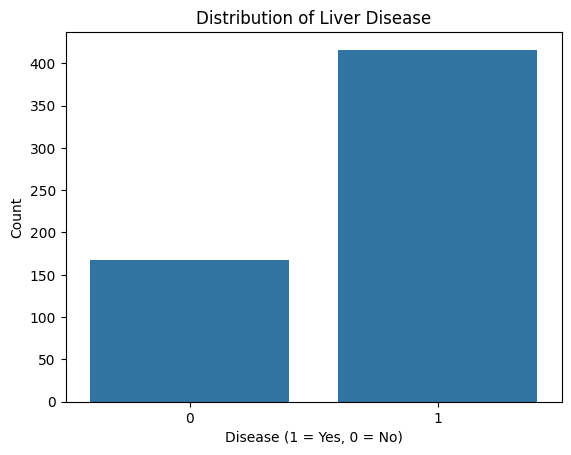

In [ ]:
sns.countplot(x=y)
plt.title("Distribution of Liver Disease")
plt.xlabel("Disease (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

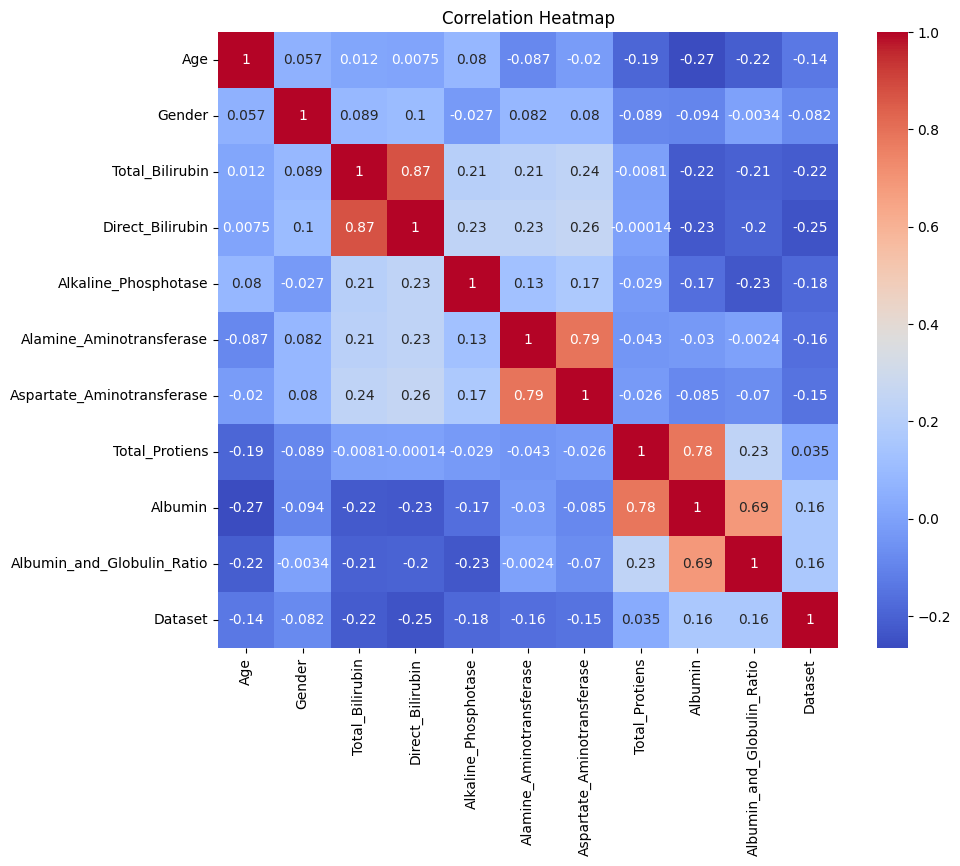

In [ ]:
# Correlation heatmap :Shows relationship between features dentify important features influencing liver disease.
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

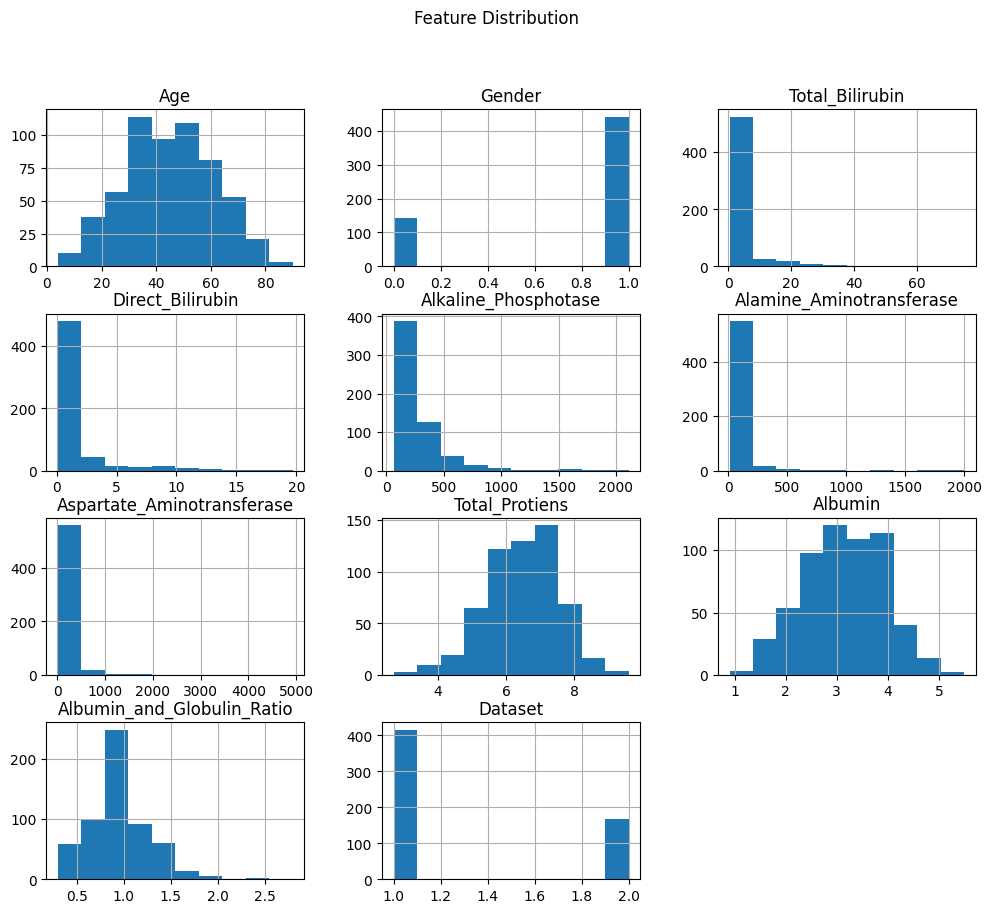

In [ ]:
# Histogram: Understand data spread

df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

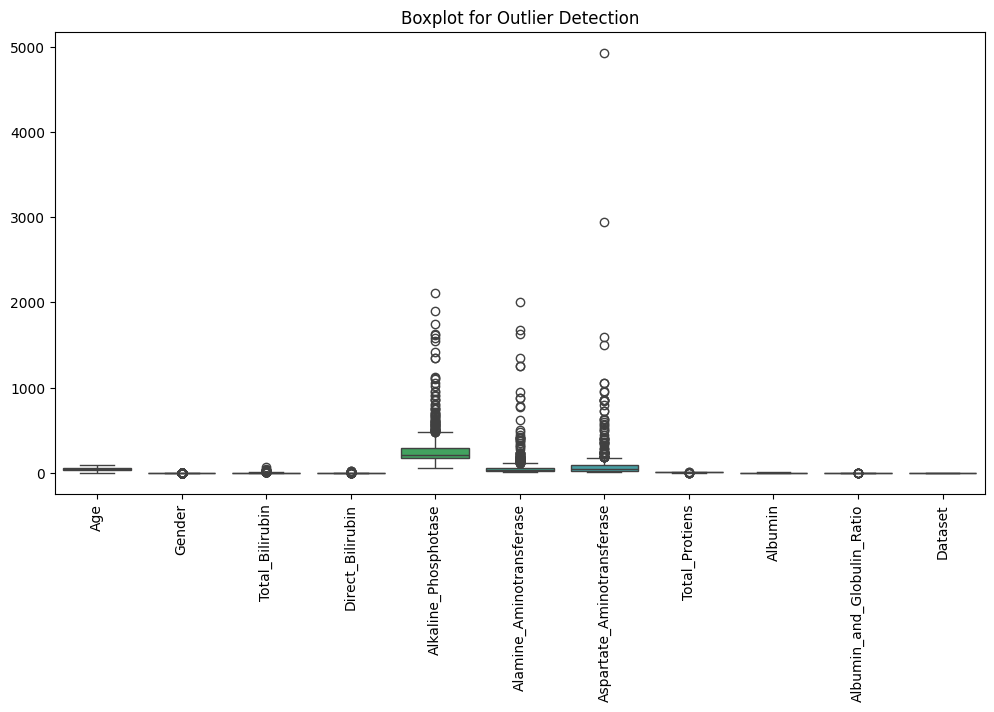

In [ ]:
# Boxplot (Outlier Detection)

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

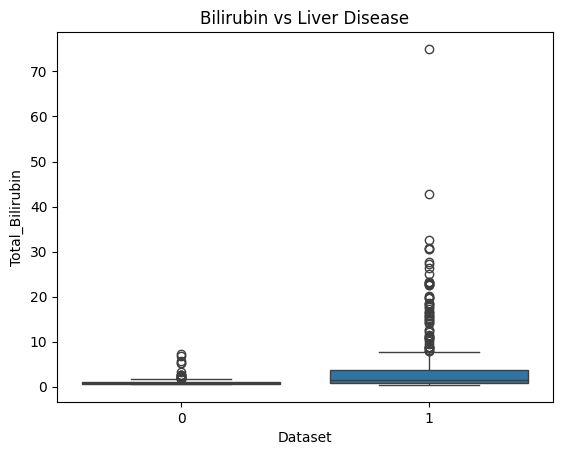

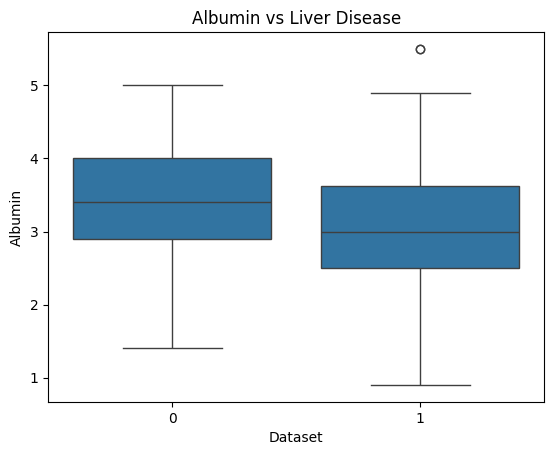

In [ ]:
#  Disease vs Important Features: See how features differ between disease vs no disease

# Example 1: Bilirubin
sns.boxplot(x=y, y=df['Total_Bilirubin'])
plt.title("Bilirubin vs Liver Disease")
plt.show()

# Example 2: Albumin
sns.boxplot(x=y, y=df['Albumin'])
plt.title("Albumin vs Liver Disease")
plt.show()

# So, dieased patients have:
# Higher bilirubin
# Lower albumin

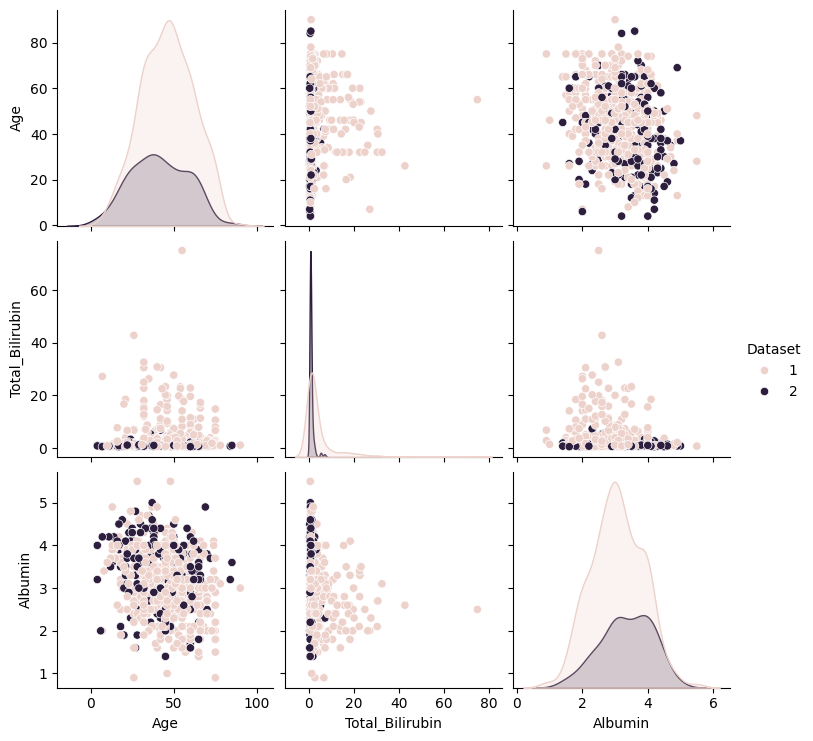

In [ ]:
# Pairplot : Shows relationships between multiple features

sns.pairplot(df[['Age','Total_Bilirubin','Albumin','Dataset']], hue='Dataset')
plt.show()

# **STEP 4: FEATURE SELECTION & MODEL BUILDING**


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
4,Alkaline_Phosphotase,0.143114
2,Total_Bilirubin,0.132726
6,Aspartate_Aminotransferase,0.131924
3,Direct_Bilirubin,0.123210
0,Age,0.107412
5,Alamine_Aminotransferase,0.105241
8,Albumin,0.081559
9,Albumin_and_Globulin_Ratio,0.079237
7,Total_Protiens,0.078301
1,Gender,0.017275


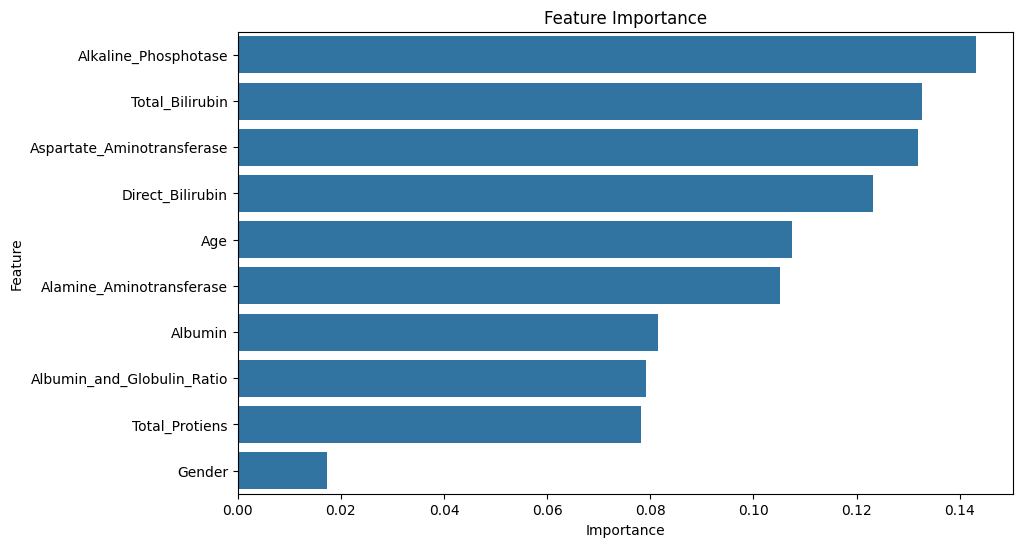

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
# Model 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
# Model 4: Support Vector Machine
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)


In [ ]:
# Model 5: K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
# Evaluate Models Comparison


print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.6410256410256411
Decision Tree: 0.7264957264957265
Random Forest: 0.7094017094017094
SVM: 0.6153846153846154
KNN: 0.5299145299145299


In [ ]:
#Handle Class imbalance
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced'
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# After handling class imbalance using class weighting, Random Forest achieved the most balanced performance and was selected as the final model.

In [ ]:

from sklearn.metrics import classification_report

print("Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Decision Tree:

              precision    recall  f1-score   support

           0       0.44      0.97      0.60        30
           1       0.98      0.57      0.72        87

    accuracy                           0.68       117
   macro avg       0.71      0.77      0.66       117
weighted avg       0.84      0.68      0.69       117

Random Forest:

              precision    recall  f1-score   support

           0       0.48      0.77      0.59        30
           1       0.90      0.71      0.79        87

    accuracy                           0.73       117
   macro avg       0.69      0.74      0.69       117
weighted avg       0.79      0.73      0.74       117



In [ ]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.6410256410256411
Decision Tree: 0.6752136752136753
Random Forest: 0.7264957264957265
SVM: 0.6153846153846154
KNN: 0.5299145299145299


In [ ]:
# Using XGBoost

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.53      0.60      0.56        30
           1       0.86      0.82      0.84        87

    accuracy                           0.76       117
   macro avg       0.69      0.71      0.70       117
weighted avg       0.77      0.76      0.77       117



In [ ]:
# Use Cross validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.689537282640731


In [ ]:
# Detailed report (RANDOM FOREST)

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:

              precision    recall  f1-score   support

           0       0.48      0.77      0.59        30
           1       0.90      0.71      0.79        87

    accuracy                           0.73       117
   macro avg       0.69      0.74      0.69       117
weighted avg       0.79      0.73      0.74       117



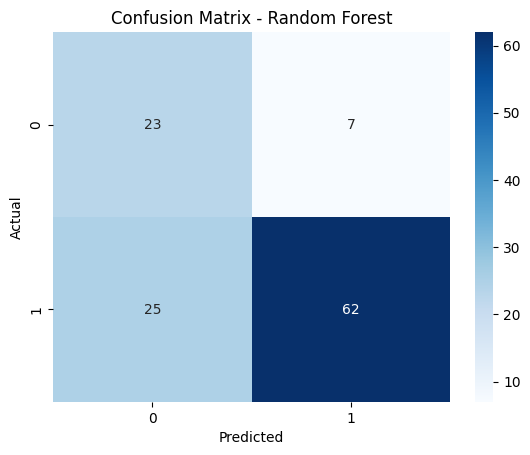

In [ ]:
# CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

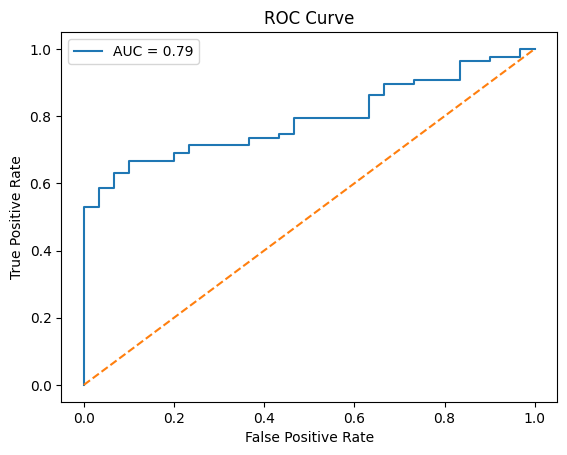

In [ ]:
# ROC Curve
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# COMPARISON

results = pd.DataFrame({
    'Model': ['LR','DT','RF','SVM','KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy
0,LR,0.641026
1,DT,0.675214
2,RF,0.726496
3,SVM,0.615385
4,KNN,0.529915


# **STEP 5 — Mortality Prediction Model**
After detecting liver disease → predict risk of death (mortality)

In [ ]:
# Create Mortality Target

# High risk if:   High Bilirubin    Low Albumin   High SGOT/SGPT

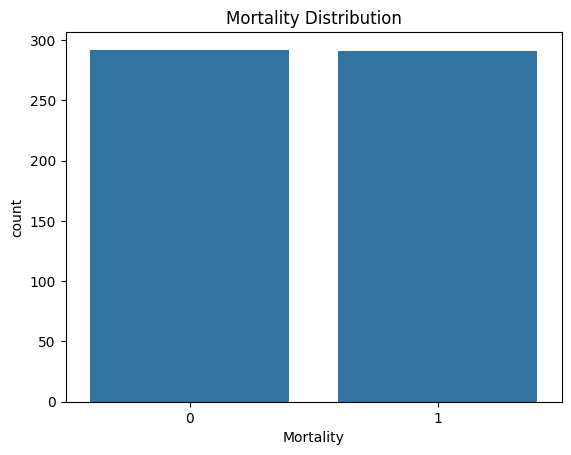

In [ ]:
X_mort = df.drop([
    'Dataset',
    'Mortality',
    'risk_score',
    'Total_Bilirubin',
    'Albumin',
    'Aspartate_Aminotransferase',
    'Age'
], axis=1)

y_mort = df['Mortality']

# Create mortality risk column

df['risk_score'] = 0

df['risk_score'] += (df['Total_Bilirubin'] > 2.0).astype(int)
df['risk_score'] += (df['Albumin'] < 3.5).astype(int)
df['risk_score'] += (df['Aspartate_Aminotransferase'] > 80).astype(int)
df['risk_score'] += (df['Age'] > 50).astype(int)

# Now define mortality
df['Mortality'] = df['risk_score'].apply(lambda x: 1 if x >= 2 else 0)

# Check Distribution

sns.countplot(x=df['Mortality'])
plt.title("Mortality Distribution")
plt.show()



In [ ]:
# Train-Test Split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mort, y_mort, test_size=0.2, random_state=42
)
# Disease model features
disease_features = X.columns.tolist()

# Mortality model features
mortality_features = X_mort.columns.tolist()

# SMOTE
sm = SMOTE(random_state=42)
X_train_m, y_train_m = sm.fit_resample(X_train_m, y_train_m)

# Scaling

scaler_m = StandardScaler()

X_train_m = scaler_m.fit_transform(X_train_m)
X_test_m = scaler_m.transform(X_test_m)

In [ ]:
# Train Model (Random Forest)
rf_m = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_m.fit(X_train_m, y_train_m)

y_pred_m = rf_m.predict(X_test_m)

# Evaluate Model
print(classification_report(y_test_m, y_pred_m))
# 100% accuracy due to data leakage

              precision    recall  f1-score   support

           0       0.77      0.89      0.82        55
           1       0.89      0.76      0.82        62

    accuracy                           0.82       117
   macro avg       0.83      0.82      0.82       117
weighted avg       0.83      0.82      0.82       117



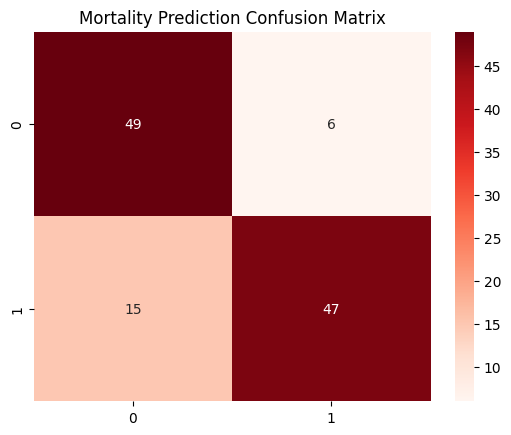

In [ ]:
cm = confusion_matrix(y_test_m, y_pred_m)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Mortality Prediction Confusion Matrix")
plt.show()

In [ ]:
# Convert to Risk Levels: Instead of 0/1, make it realistic:

def risk_level(pred):
    if pred == 0:
        return "Low Risk"
    elif pred == 1:
        return "High Risk"

predictions = [risk_level(p) for p in y_pred_m]

In [ ]:
def predict_patient(data):

    # Create DataFrame with correct column names
    input_data = pd.DataFrame([data], columns=disease_features)

    # ---- Disease Prediction ----
    input_scaled = scaler.transform(input_data)
    disease = rf.predict(input_scaled)[0]

    if disease == 1:

        # Select only mortality features
        input_mort = input_data[mortality_features]

        # Scale
        input_scaled_m = scaler_m.transform(input_mort)

        # Predict
        mortality = rf_m.predict(input_scaled_m)[0]

        if mortality == 1:
            return "Disease Detected - High Mortality Risk"
        else:
            return "Disease Detected - Low Mortality Risk"

    else:
        return "No Liver Disease"

sample = [45,1,3.5,1.2,200,120,130,6.5,2.8,0.8]

print(predict_patient(sample))

Disease Detected - High Mortality Risk


# **STEP 6 — FINAL INTEGRATION + MODEL SAVING + DEPLOYMENT**

In [ ]:
# Save Disease Model

pickle.dump(rf, open('disease_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# Save Mortality Model

pickle.dump(rf_m, open('mortality_model.pkl', 'wb'))
pickle.dump(scaler_m, open('scaler_m.pkl', 'wb'))

# Save Feature Names
pickle.dump(disease_features, open('disease_features.pkl', 'wb'))
pickle.dump(mortality_features, open('mortality_features.pkl', 'wb'))

In [ ]:
from google.colab import files

files.download('disease_model.pkl')
files.download('scaler.pkl')
files.download('mortality_model.pkl')
files.download('scaler_m.pkl')
files.download('disease_features.pkl')
files.download('mortality_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>